<a href="https://colab.research.google.com/github/stellarminnie/Scanine/blob/main/FinalTrainingforFurnsics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Paths
base = "/content/drive/MyDrive/furnsics_ringworm"
dataset_dir = f"{base}/dataset"
model_save_dir = f"{base}/models"

import os
os.makedirs(model_save_dir, exist_ok=True)

print("Drive mounted and paths set! ✅")

Mounted at /content/drive
Drive mounted and paths set! ✅


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Image settings
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 30
NUM_CLASSES = 1          # binary classification
SEED        = 42

# Class names
CLASSES = ["ringworm_negative", "ringworm_positive"]

print("Config set! ✅")

Config set! ✅


In [ ]:
# Training generator — with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Val and Test generators — NO augmentation, only rescale
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load train
train_gen = train_datagen.flow_from_directory(
    f"{dataset_dir}/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED,
    shuffle=True
)

# Load val
val_gen = val_test_datagen.flow_from_directory(
    f"{dataset_dir}/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED,
    shuffle=False
)

# Load test
test_gen = val_test_datagen.flow_from_directory(
    f"{dataset_dir}/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED,
    shuffle=False
)

print(f"Class indices: {train_gen.class_indices}")
print(f"Train batches: {len(train_gen)}")
print(f"Val batches:   {len(val_gen)}")
print(f"Test batches:  {len(test_gen)}")

Found 1980 images belonging to 2 classes.
Found 423 images belonging to 2 classes.
Found 426 images belonging to 2 classes.
Class indices: {'ringworm_negative': 0, 'ringworm_positive': 1}
Train batches: 62
Val batches:   14
Test batches:  14


In [ ]:
# Load MobileNetV3-Small pretrained on ImageNet
base_model = MobileNetV3Small(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True
)

# Freeze base model first (feature extraction phase)
base_model.trainable = False

# Build classifier on top
inputs  = tf.keras.Input(shape=(*IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)  # binary output

model = models.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 576)            │         2,304 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,015,409 (3.87 MB)

 Trainable params: 75,137 (293.50 KB)

 Non-trainable params: 940,272 (3.59 MB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")
print(f"Class indices: {train_gen.class_indices}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

callbacks = [
    ModelCheckpoint(
        filepath=f"{model_save_dir}/best_phase1.keras",  # ← separate file
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_auc',
        patience=7,              # ← more patience this time
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

print("Training Phase 1 — Frozen base...")
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,                   # ← more epochs, let early stopping decide
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Class weights: {0: np.float64(1.0206185567010309), 1: np.float64(0.9801980198019802)}
Class indices: {'ringworm_negative': 0, 'ringworm_positive': 1}
Training Phase 1 — Frozen base...
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - accuracy: 0.6538 - auc: 0.7206 - loss: 0.6130 - precision: 0.6957 - recall: 0.5340
Epoch 1: val_auc improved from None to 0.81165, saving model to /content/drive/MyDrive/furnsics_ringworm/models/best_phase1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/furnsics_ringworm/models/best_phase1.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 70s 920ms/step - accuracy: 0.6980 - auc: 0.7797 - loss: 0.5703 - precision: 0.7336 - recall: 0.6406 - val_accuracy: 0.5106 - val_auc: 0.8117 - val_loss: 0.7643 - val_precision: 0.5106 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.7550 - auc: 0.8340 - loss: 0.5069 - precision: 0.7388 - recall: 0.7977
Epoch 2: val_auc improved from 0.81165 to 0.84765, savi

In [ ]:
# Skip fine-tuning — load best Phase 1 model
model = tf.keras.models.load_model(f"{model_save_dir}/best_phase1.keras")
print("Best Phase 1 model loaded ✅")

Best Phase 1 model loaded ✅


In [ ]:
import sys
# First, uninstall potentially conflicting packages to ensure a clean install.
# This helps prevent issues from partial uninstallation or conflicting versions.
!pip uninstall -y tensorflow tensorflow-decision-forests tensorflowjs tf-keras tensorboard

# Install tensorflow==2.19.0 which is compatible with tensorflow-decision-forests 1.12.0.
# Using --break-system-packages to handle potential conflicts with system-installed packages.
!pip install tensorflow==2.19.0 --break-system-packages

# Now install tensorflowjs. It should now find a compatible tensorflow version
# (2.19.0) for its dependency tensorflow-decision-forests.
!pip install tensorflowjs --break-system-packages

# It's crucial to restart the runtime after such major package changes
# to ensure all components load correctly with the new versions.
# However, since the instruction is to fix the code within the cell, we'll proceed,
# but be aware a manual runtime restart might still be necessary if issues persist.
if 'google.colab' in sys.modules:
    print("\n--- IMPORTANT: Please restart your Colab runtime (Runtime > Restart runtime) now ---")

import tensorflowjs as tfjs
import tensorflow as tf

# Load your saved model
# Note: If the model was trained with tf 2.20.0, and we are now using tf 2.19.0,
# there might be minor compatibility issues, but typically not critical for minor version changes.
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/furnsics_ringworm/models/best_phase1.keras"
)

# Convert and save to TF.js format
tfjs.converters.save_keras_model(
    model,
    "/content/drive/MyDrive/furnsics_ringworm/models/tfjs_model"
)

print("Conversion done! ✅")
print("Files saved to tfjs_model/")

Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: tensorflow_decision_forests 1.12.0
Uninstalling tensorflow_decision_forests-1.12.0:
  Successfully uninstalled tensorflow_decision_forests-1.12.0
Found existing installation: tensorflowjs 4.22.0
Uninstalling tensorflowjs-4.22.0:
  Successfully uninstalled tensorflowjs-4.22.0
Found existing installation: tf_keras 2.19.0
Uninstalling tf_keras-2.19.0:
  Successfully uninstalled tf_keras-2.19.0
Found existing installation: tensorboard 2.19.0
Uninstalling tensorboard-2.19.0:
  Successfully uninstalled tensorboard-2.19.0
  Using cached tensorflow-2.19.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached tensorboard-2.19.0-py3-none-any.whl.metadata (1.8 kB)
Using cached tensorflow-2.19.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (645.0 MB)
Using cached tensorboard-2.19.0-py3-none-any.w

failed to lookup keras version from the file,
    this is likely a weight only file
Conversion done! ✅
Files saved to tfjs_model/


In [ ]:
import os

tfjs_dir = "/content/drive/MyDrive/furnsics_ringworm/models/tfjs_model"

print("Files in tfjs_model folder:")
for f in os.listdir(tfjs_dir):
    size = os.path.getsize(f"{tfjs_dir}/{f}")
    print(f"  {f}  ({size:,} bytes)")

Files in tfjs_model folder:
  group1-shard1of1.bin  (4,061,636 bytes)
  model.json  (158,244 bytes)


In [ ]:
import json
import re

tfjs_dir = "/content/drive/MyDrive/furnsics_ringworm/models/tfjs_model"
model_json_path = f"{tfjs_dir}/model.json"

# ── Load ───────────────────────────────────────────────────────────
with open(model_json_path, 'r') as f:
    content = f.read()

# ── PASS 1: String-level replacements (initializers & activations) ─
string_patches = [
    # Initializers
    ('"glorot_uniform"',   '"glorotUniform"'),
    ('"glorot_normal"',    '"glorotNormal"'),
    ('"he_uniform"',       '"heUniform"'),
    ('"he_normal"',        '"heNormal"'),
    ('"lecun_uniform"',    '"lecunUniform"'),
    ('"lecun_normal"',     '"lecunNormal"'),
    ('"truncated_normal"', '"truncatedNormal"'),
    ('"random_uniform"',   '"randomUniform"'),
    ('"random_normal"',    '"randomNormal"'),
    ('"variance_scaling"', '"varianceScaling"'),
    # Activations
    ('"leaky_relu"',       '"leakyRelu"'),
    ('"hard_sigmoid"',     '"hardSigmoid"'),
    ('"soft_plus"',        '"softplus"'),
    # Regularizers
    ('"l1_l2"',            '"L1L2"'),
    # Padding
    ('"same"',             '"same"'),
    ('"causal"',           '"causal"'),
    # Class names that changed
    ('"BatchNormalization"', '"BatchNormalization"'),  # unchanged but verified
]

for old, new in string_patches:
    content = content.replace(old, new)

# ── PASS 2: JSON-level structural fixes ───────────────────────────
model_json = json.loads(content)

def fix_node(obj):
    if isinstance(obj, dict):

        # Fix 1 — InputLayer: batch_shape → batchInputShape
        if 'batch_shape' in obj:
            obj['batchInputShape'] = obj.pop('batch_shape')
        if 'batch_input_shape' in obj:
            obj['batchInputShape'] = obj.pop('batch_input_shape')

        # Fix 2 — InputLayer: sparse/ragged keys TF.js doesn't understand
        for key in ['sparse', 'ragged']:
            obj.pop(key, None)

        # Fix 3 — Rename 'groups' to nothing (not supported in old TF.js)
        # Only remove if it's the default value of 1
        if obj.get('groups') == 1:
            obj.pop('groups', None)

        # Fix 4 — BatchNormalization: 'axis' must be an int not a list
        if obj.get('class_name') == 'BatchNormalization':
            cfg = obj.get('config', {})
            if isinstance(cfg.get('axis'), list):
                cfg['axis'] = cfg['axis'][0]

        # Fix 5 — Remove 'dtype' policy objects (Keras 3 mixed precision)
        if isinstance(obj.get('dtype'), dict):
            obj['dtype'] = 'float32'

        # Fix 6 — Rename 'module' key (Keras 3 adds this, TF.js ignores but errors)
        obj.pop('module', None)

        # Fix 7 — Rename 'build_config' (Keras 3 specific)
        obj.pop('build_config', None)

        # Fix 8 — Rename 'compile_config' (Keras 3 specific)
        obj.pop('compile_config', None)

        # Fix 9 — Ensure 'trainable' is always a bool
        if 'trainable' in obj and not isinstance(obj['trainable'], bool):
            obj['trainable'] = bool(obj['trainable'])

        # Fix 10 — activation stored as dict instead of string
        if isinstance(obj.get('activation'), dict):
            act = obj['activation']
            if 'class_name' in act:
                obj['activation'] = act['class_name'].lower()

        # Recurse into all values
        for value in list(obj.values()):
            fix_node(value)

    elif isinstance(obj, list):
        for item in obj:
            fix_node(item)

fix_node(model_json)

# ── PASS 3: Fix keras_version to something TF.js accepts ──────────
if 'modelTopology' in model_json:
    topology = model_json['modelTopology']
    if 'keras_version' in topology:
        topology['keras_version'] = '2.11.0'  # spoof a TF.js-compatible version
    if 'backend' in topology:
        topology['backend'] = 'tensorflow'

# ── Save ───────────────────────────────────────────────────────────
with open(model_json_path, 'w') as f:
    json.dump(model_json, f)

print("=" * 50)
print("✅ All patches applied successfully!")
print("=" * 50)
print("Patches applied:")
print("  ✓ Initializer names (glorotUniform, heNormal, etc.)")
print("  ✓ InputLayer batch_shape → batchInputShape")
print("  ✓ Removed sparse/ragged/module/build_config keys")
print("  ✓ BatchNormalization axis list → int")
print("  ✓ dtype policy objects → float32")
print("  ✓ Activation dict → string")
print("  ✓ keras_version spoofed to 2.11.0")
print("  ✓ groups=1 removed")
print("=" * 50)
print("\n👉 Re-download model.json and replace it in pwa_app/public/model/")
print("👉 The .bin file does NOT need to be re-downloaded")

✅ All patches applied successfully!
Patches applied:
  ✓ Initializer names (glorotUniform, heNormal, etc.)
  ✓ InputLayer batch_shape → batchInputShape
  ✓ Removed sparse/ragged/module/build_config keys
  ✓ BatchNormalization axis list → int
  ✓ dtype policy objects → float32
  ✓ Activation dict → string
  ✓ keras_version spoofed to 2.11.0
  ✓ groups=1 removed

👉 Re-download model.json and replace it in pwa_app/public/model/
👉 The .bin file does NOT need to be re-downloaded


In [ ]:
# Step 1 — Install tensorflowjs
!pip install tensorflowjs

# Step 2 — Verify installation
import tensorflowjs as tfjs
print(f"TensorFlow.js converter version: {tfjs.__version__} ✅")

TensorFlow.js converter version: 4.22.0 ✅


In [ ]:
import tensorflow as tf
import tensorflowjs as tfjs
import json

# Step 1 — Load your best model
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/furnsics_ringworm/models/best_phase1.keras"
)

# Step 2 — Convert to a Sequential-compatible format
# Save as TF SavedModel format first (not .keras)
model.export(
    "/content/drive/MyDrive/furnsics_ringworm/models/saved_model_export"
)

# Step 3 — Convert from SavedModel to TF.js
tfjs_output = "/content/drive/MyDrive/furnsics_ringworm/models/tfjs_model_v2"

import subprocess
result = subprocess.run([
    "tensorflowjs_converter",
    "--input_format=tf_saved_model",
    "--output_format=tfjs_graph_model",   # ← graph_model not layers_model
    "--signature_name=serving_default",
    "--saved_model_tags=serve",
    "/content/drive/MyDrive/furnsics_ringworm/models/saved_model_export",
    tfjs_output
], capture_output=True, text=True)

print(result.stdout)
print(result.stderr)
print("Done! ✅")

Saved artifact at '/content/drive/MyDrive/furnsics_ringworm/models/saved_model_export'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133454240490000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133454240491728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133454240492112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133454240490960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133454240492688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133454240491344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133454240492304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133454240492496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133454240488848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133454240493648: TensorSpec(shape

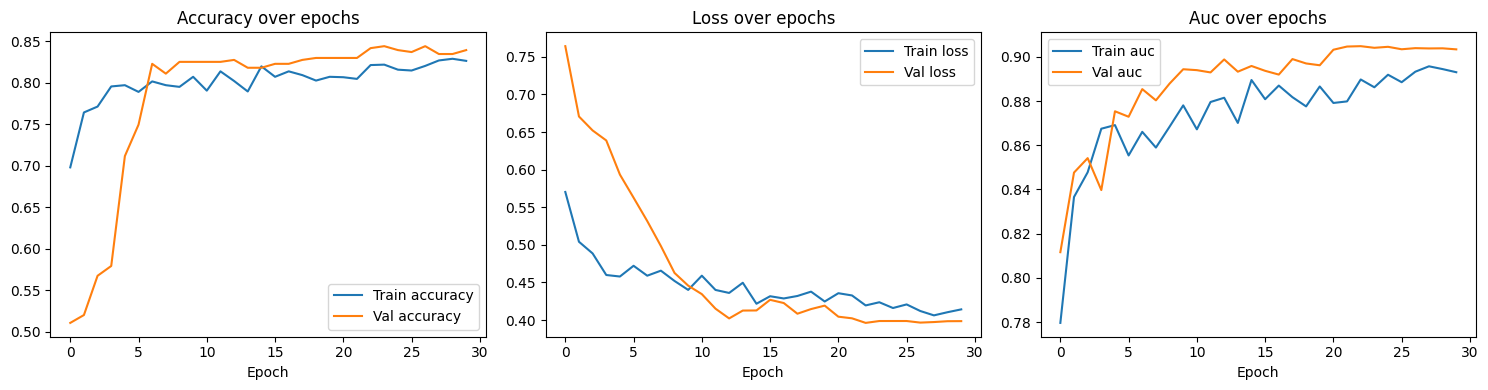

Training history saved ✅


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))

metrics_to_plot = ['accuracy', 'loss', 'auc']
for i, metric in enumerate(metrics_to_plot):
    plt.subplot(1, 3, i+1)
    plt.plot(history1.history[metric], label=f'Train {metric}')
    plt.plot(history1.history[f'val_{metric}'], label=f'Val {metric}')
    plt.title(f'{metric.capitalize()} over epochs')
    plt.xlabel('Epoch')
    plt.legend()

plt.tight_layout()
plt.savefig(f"{model_save_dir}/training_history.png")
plt.show()
print("Training history saved ✅")

In [ ]:
print("Evaluating on test set...")
results = model.evaluate(test_gen, verbose=1)

metrics = ['loss', 'accuracy', 'precision', 'recall', 'auc']
print("\n=== Test Results ===")
for name, value in zip(metrics, results):
    print(f"{name.capitalize():<12}: {value:.4f}")

Evaluating on test set...
14/14 ━━━━━━━━━━━━━━━━━━━━ 311s 23s/step - accuracy: 0.8192 - auc: 0.9055 - loss: 0.4008 - precision: 0.7823 - recall: 0.8940

=== Test Results ===
Loss        : 0.4008
Accuracy    : 0.8192
Precision   : 0.7823
Recall      : 0.8940
Auc         : 0.9055


In [ ]:
# Save final model
model.save(f"{model_save_dir}/derring_model_final.keras")
print(f"Model saved to {model_save_dir} ✅")

# Also print model summary for your records
print("\n=== Model Summary ===")
print(f"Input shape:  {model.input_shape}")
print(f"Output shape: {model.output_shape}")
print(f"Total params: {model.count_params():,}")

Model saved to /content/drive/MyDrive/furnsics_ringworm/models ✅

=== Model Summary ===
Input shape:  (None, 224, 224, 3)
Output shape: (None, 1)
Total params: 1,015,409


14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/step


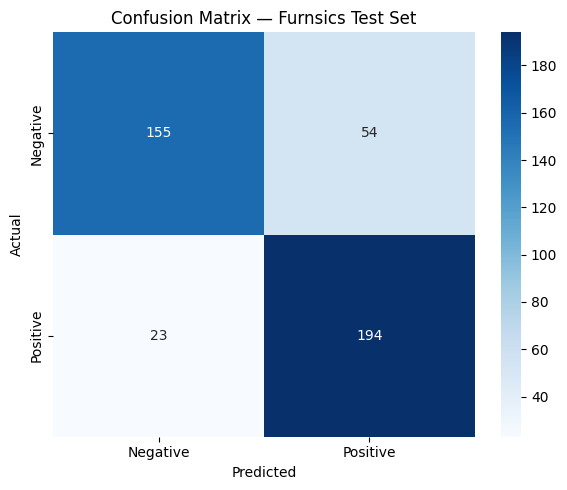

                   precision    recall  f1-score   support

ringworm_negative       0.87      0.74      0.80       209
ringworm_positive       0.78      0.89      0.83       217

         accuracy                           0.82       426
        macro avg       0.83      0.82      0.82       426
     weighted avg       0.83      0.82      0.82       426



In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()
y_true = test_gen.classes

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix — Furnsics Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f"{model_save_dir}/confusion_matrix.png")
plt.show()

# Classification report
print(classification_report(y_true, y_pred,
      target_names=['ringworm_negative', 'ringworm_positive']))

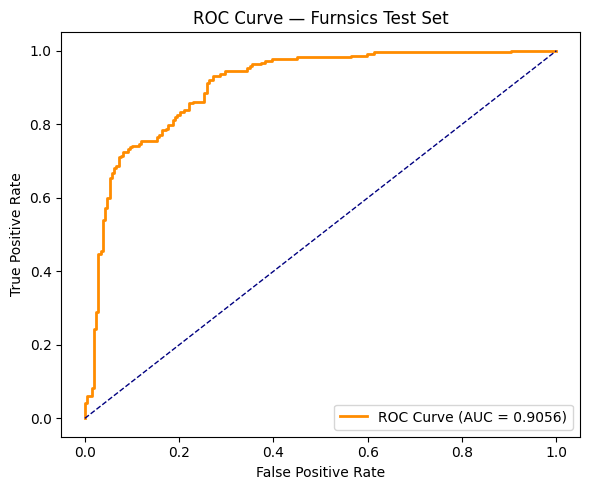

In [ ]:
# ROC Curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Furnsics Test Set')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f"{model_save_dir}/roc_curve.png")
plt.show()

In [ ]:
for i, layer in enumerate(model.layers):
    try:
        shape = str(layer.output.shape)
    except:
        shape = "n/a"
    print(f"{i:3d}  {layer.name:60s}  {shape}")

  0  input_layer_3                                                 (None, 224, 224, 3)
  1  MobileNetV3Small                                              (None, 7, 7, 576)
  2  global_average_pooling2d_1                                    (None, 576)
  3  batch_normalization_1                                         (None, 576)
  4  dropout_2                                                     (None, 576)
  5  dense_2                                                       (None, 128)
  6  dropout_3                                                     (None, 128)
  7  dense_3                                                       (None, 1)


In [ ]:
# Unwrap the inner MobileNetV3 model
base = model.get_layer('MobileNetV3Small')

# Print all internal layers
for i, layer in enumerate(base.layers):
    try:
        shape = str(layer.output.shape)
    except:
        shape = "n/a"
    print(f"{i:3d}  {layer.name:50s}  {shape}")

  0  input_layer_2                                       (None, 224, 224, 3)
  1  rescaling_1                                         (None, 224, 224, 3)
  2  conv                                                (None, 112, 112, 16)
  3  conv_bn                                             (None, 112, 112, 16)
  4  activation_18                                       (None, 112, 112, 16)
  5  expanded_conv_depthwise_pad                         (None, 113, 113, 16)
  6  expanded_conv_depthwise                             (None, 56, 56, 16)
  7  expanded_conv_depthwise_bn                          (None, 56, 56, 16)
  8  re_lu_14                                            (None, 56, 56, 16)
  9  expanded_conv_squeeze_excite_avg_pool               (None, 1, 1, 16)
 10  expanded_conv_squeeze_excite_conv                   (None, 1, 1, 8)
 11  expanded_conv_squeeze_excite_relu                   (None, 1, 1, 8)
 12  expanded_conv_squeeze_excite_conv_1                 (None, 1, 1, 16)
 13  re_lu_1

Image loaded successfully ✅


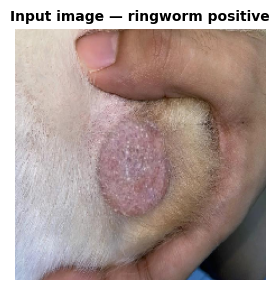

Reference image saved ✅
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


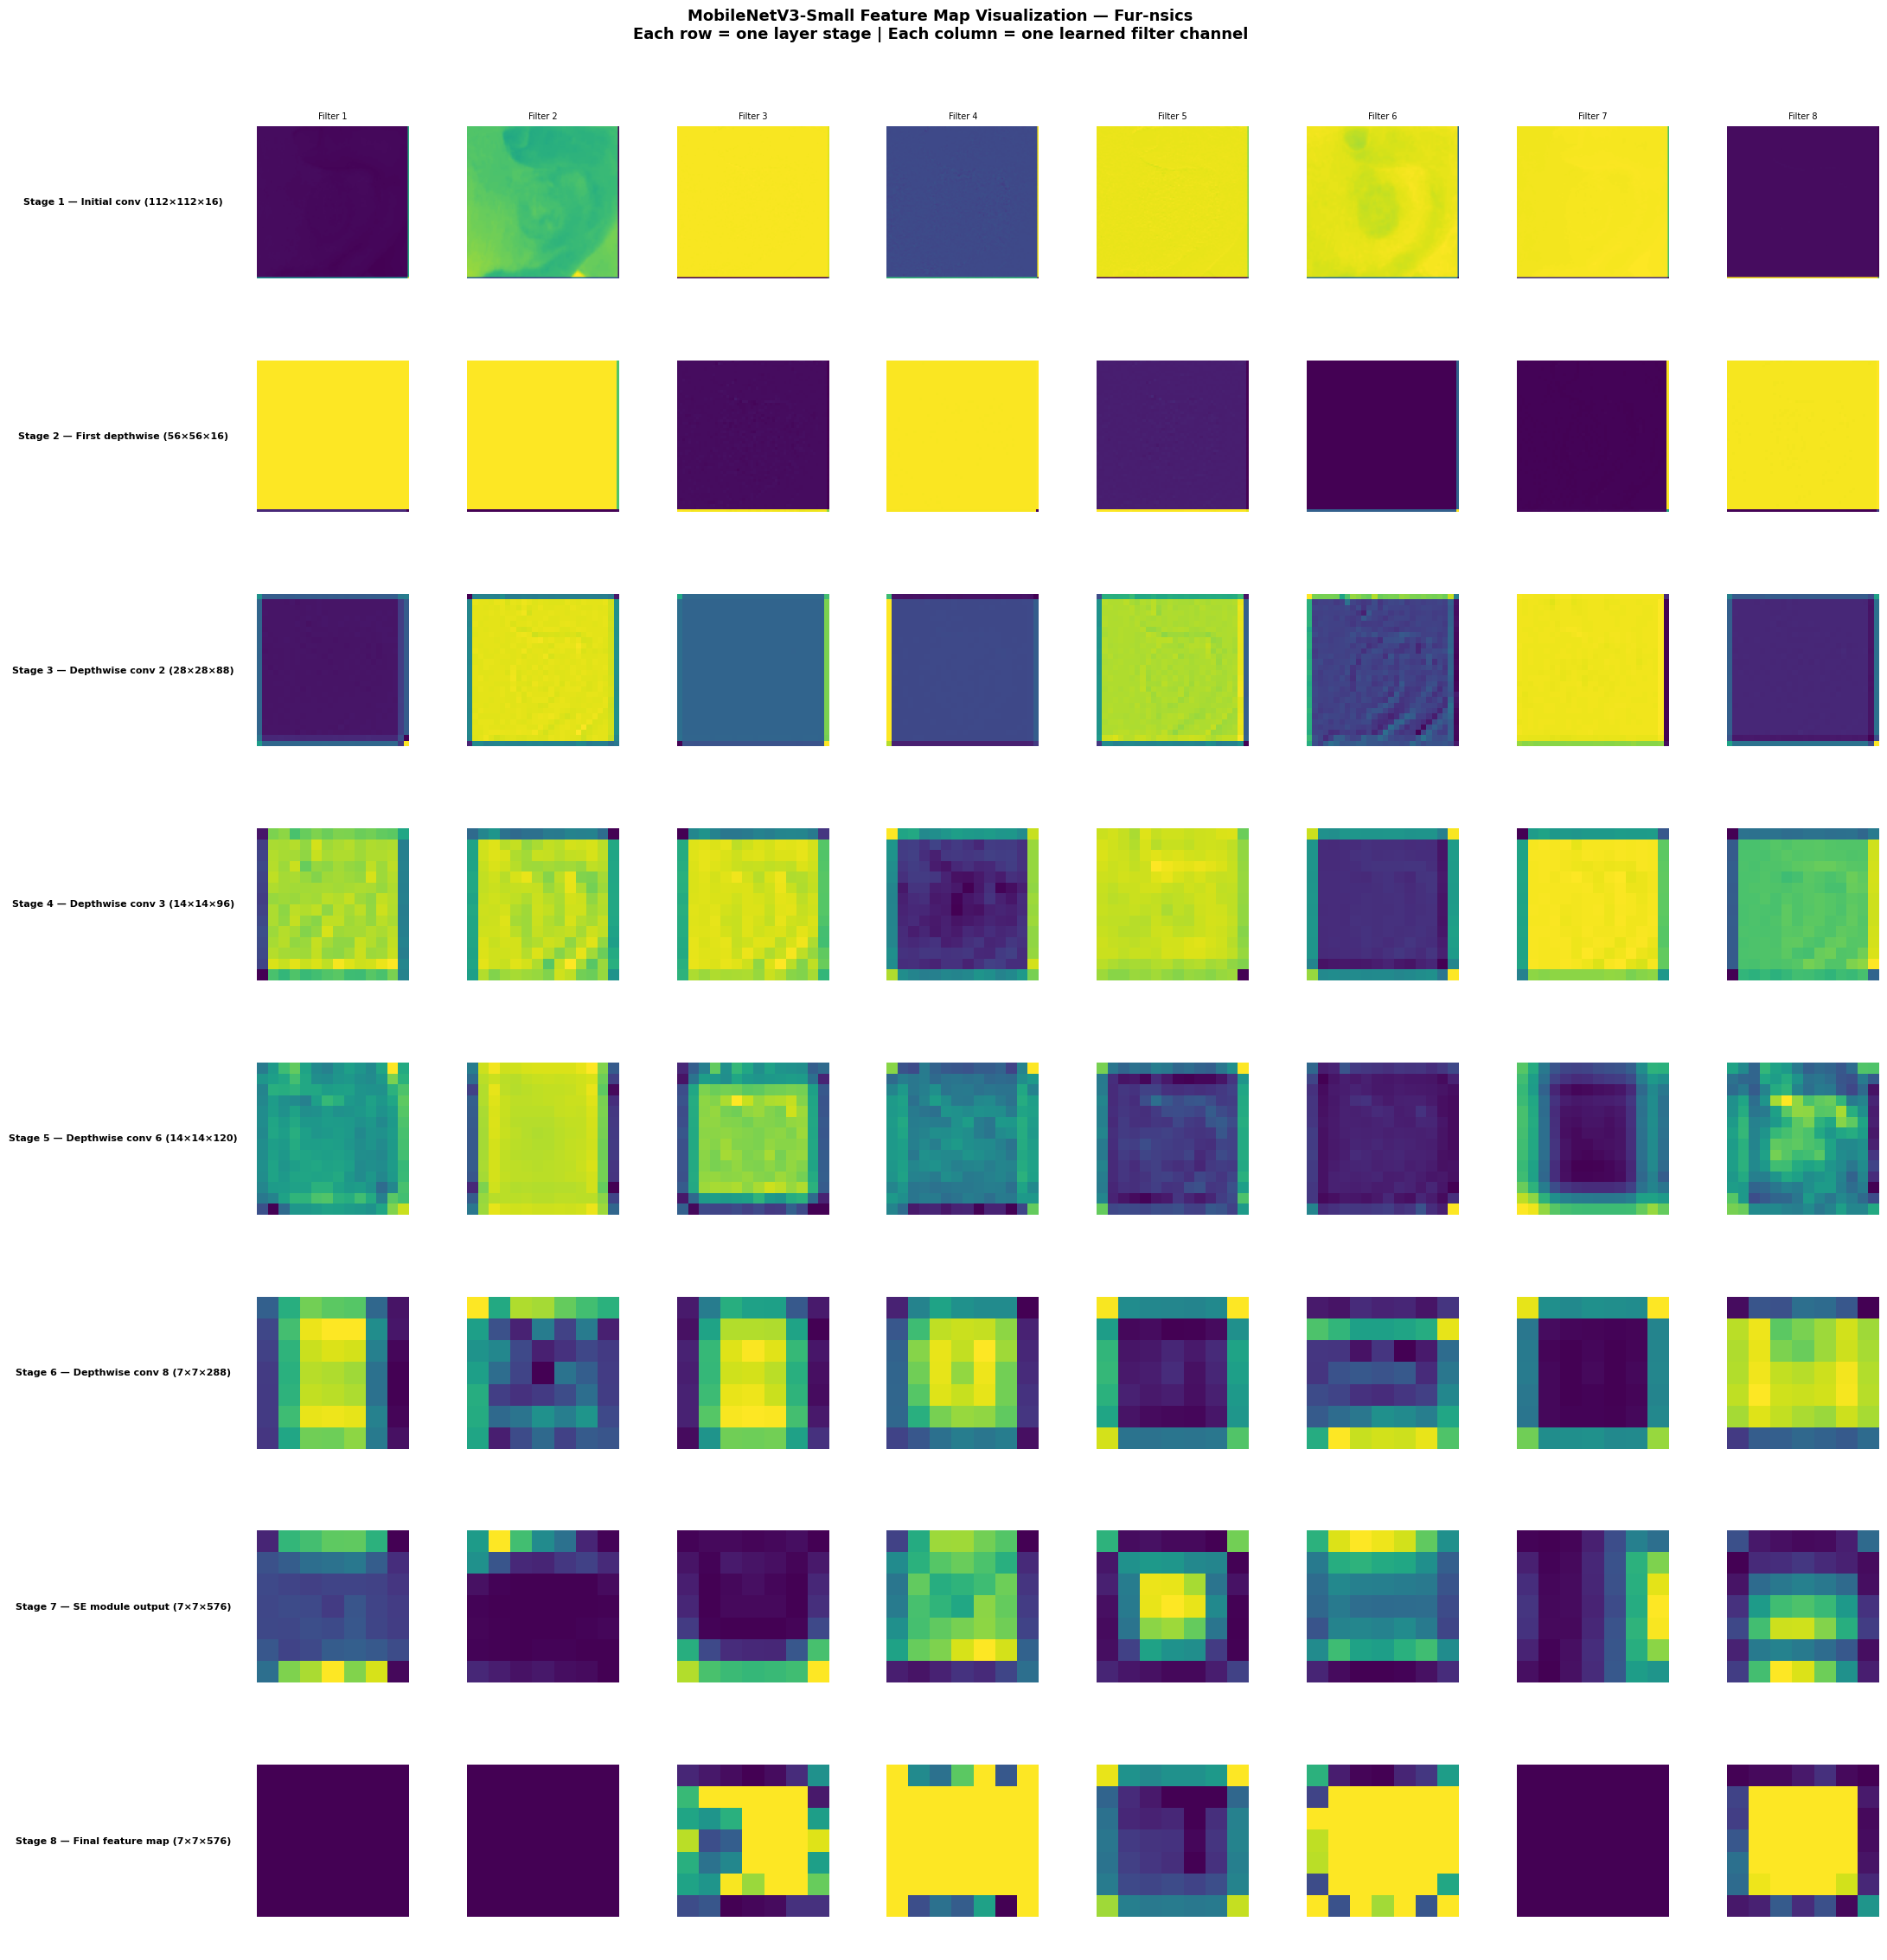

Feature maps saved to /content/drive/MyDrive/furnsics_ringworm/models/feature_maps.png ✅


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import tensorflow as tf
import os

# Step 1 — Load specific image
img_path = "/content/drive/MyDrive/furnsics_ringworm/dataset/test/ringworm_positive/4A3D587D-87FB-42C3-9265-29B9DC144776_jpeg_jpg.rf.fb2c3e424de45f755ee142d17be95e0e.jpg"

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 127.5 - 1.0
img_tensor = np.expand_dims(img_array, axis=0)
print("Image loaded successfully ✅")

# Step 2 — Show original image first
plt.figure(figsize=(3, 3))
original = image.load_img(img_path, target_size=(224, 224))
plt.imshow(original)
plt.axis('off')
plt.title('Input image — ringworm positive', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/furnsics_ringworm/models/input_image_reference.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
plt.close()  # ← close reference figure before opening feature map figure
print("Reference image saved ✅")

# Step 3 — Unwrap base model
base = model.get_layer('MobileNetV3Small')

# Step 4 — Select representative layers
selected_layers = [
    ('conv_bn',                            'Stage 1 — Initial conv (112×112×16)'),
    ('expanded_conv_depthwise_bn',         'Stage 2 — First depthwise (56×56×16)'),
    ('expanded_conv_2_depthwise_bn',       'Stage 3 — Depthwise conv 2 (28×28×88)'),
    ('expanded_conv_3_depthwise_bn',       'Stage 4 — Depthwise conv 3 (14×14×96)'),
    ('expanded_conv_6_depthwise_bn',       'Stage 5 — Depthwise conv 6 (14×14×120)'),
    ('expanded_conv_8_depthwise_bn',       'Stage 6 — Depthwise conv 8 (7×7×288)'),
    ('expanded_conv_9_squeeze_excite_mul', 'Stage 7 — SE module output (7×7×576)'),
    ('activation_35',                      'Stage 8 — Final feature map (7×7×576)'),
]

layer_names  = [l[0] for l in selected_layers]
layer_labels = [l[1] for l in selected_layers]

# Step 5 — Build feature extractor
feature_extractor = tf.keras.Model(
    inputs=base.input,
    outputs=[base.get_layer(name).output for name in layer_names]
)

# Step 6 — Get feature maps
feature_maps = feature_extractor.predict(img_tensor)

# Step 7 — Plot feature maps
N_FILTERS = 8
fig, axes = plt.subplots(
    len(selected_layers), N_FILTERS + 1,
    figsize=(22, len(selected_layers) * 2.8)
)

fig.suptitle(
    'MobileNetV3-Small Feature Map Visualization — Fur-nsics\n'
    'Each row = one layer stage | Each column = one learned filter channel',
    fontsize=13, fontweight='bold', y=1.01
)

for row, (label, fmap) in enumerate(zip(layer_labels, feature_maps)):
    fmap = fmap[0]
    n_available = fmap.shape[-1]

    # Column 0 — row label
    axes[row, 0].axis('off')
    axes[row, 0].text(
        0.5, 0.5, label,
        transform=axes[row, 0].transAxes,
        fontsize=8, fontweight='bold',
        va='center', ha='center',
        wrap=True
    )

    # Columns 1–8 — filter visualizations
    for col in range(N_FILTERS):
        ax = axes[row, col + 1]
        if col < n_available:
            channel = fmap[:, :, col]
            channel = (channel - channel.min()) / (channel.max() - channel.min() + 1e-8)
            ax.imshow(channel, cmap='viridis')
        ax.axis('off')
        if row == 0:
            ax.set_title(f'Filter {col+1}', fontsize=7)

plt.tight_layout()

# Step 8 — Save feature maps THEN show
save_path = "/content/drive/MyDrive/furnsics_ringworm/models/feature_maps.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')  # ← save first
plt.show()                                             # ← show after
plt.close()
print(f"Feature maps saved to {save_path} ✅")

In [ ]:
import os

# Search for the file across the entire dataset folder
base_search = "/content/drive/MyDrive/furnsics_ringworm"
target = "4A3D587D-87FB-42C3-9265-29B9DC144776"

for root, dirs, files in os.walk(base_search):
    for f in files:
        if target in f:
            print(os.path.join(root, f))

/content/drive/MyDrive/furnsics_ringworm/raw/ringworm_positive/4A3D587D-87FB-42C3-9265-29B9DC144776_jpeg_jpg.rf.fb2c3e424de45f755ee142d17be95e0e.jpg
/content/drive/MyDrive/furnsics_ringworm/dataset/test/ringworm_positive/4A3D587D-87FB-42C3-9265-29B9DC144776_jpeg_jpg.rf.fb2c3e424de45f755ee142d17be95e0e.jpg


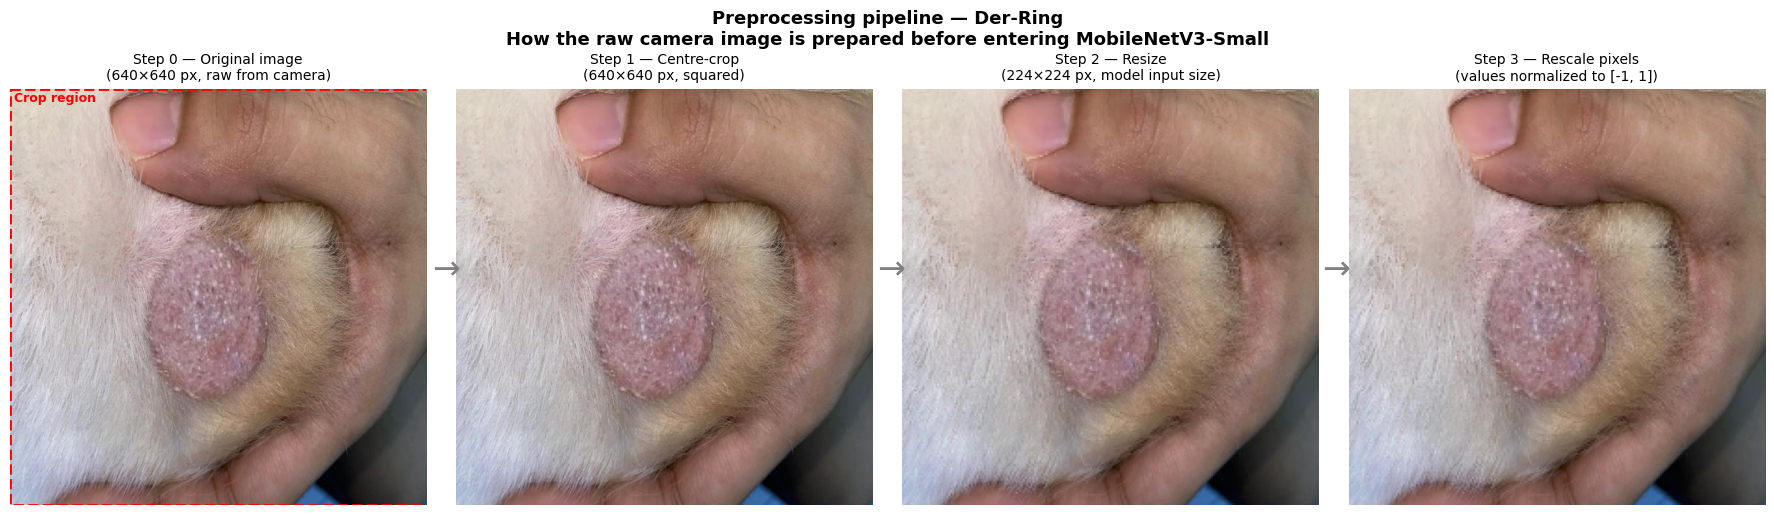

Preprocessing pipeline saved ✅


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tensorflow.keras.preprocessing import image
import tensorflow as tf

img_path = "/content/drive/MyDrive/furnsics_ringworm/dataset/test/ringworm_positive/4A3D587D-87FB-42C3-9265-29B9DC144776_jpeg_jpg.rf.fb2c3e424de45f755ee142d17be95e0e.jpg"

# ── Load original at full resolution ──────────────────────────
original = image.load_img(img_path)
original_array = image.img_to_array(original).astype('uint8')
orig_h, orig_w = original_array.shape[:2]

# ── Step 1 — Centre-crop to square ────────────────────────────
size = min(orig_h, orig_w)
sx = (orig_w - size) // 2
sy = (orig_h - size) // 2
cropped = original_array[sy:sy+size, sx:sx+size]

# ── Step 2 — Resize to 224×224 ────────────────────────────────
resized = tf.image.resize(cropped, [224, 224]).numpy().astype('uint8')

# ── Step 3 — Rescale to [-1, 1] ───────────────────────────────
rescaled = resized / 127.5 - 1.0

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(
    'Preprocessing pipeline — Der-Ring\n'
    'How the raw camera image is prepared before entering MobileNetV3-Small',
    fontsize=13, fontweight='bold', y=1.02
)

# Original
axes[0].imshow(original_array)
axes[0].set_title('Step 0 — Original image\n'
                   f'({orig_w}×{orig_h} px, raw from camera)',
                   fontsize=10)
# Draw crop box
rect = patches.Rectangle(
    (sx, sy), size, size,
    linewidth=2, edgecolor='red', facecolor='none', linestyle='--'
)
axes[0].add_patch(rect)
axes[0].text(sx+5, sy+20, 'Crop region', color='red', fontsize=9, fontweight='bold')
axes[0].axis('off')

# Cropped
axes[1].imshow(cropped)
axes[1].set_title('Step 1 — Centre-crop\n'
                   f'({size}×{size} px, squared)',
                   fontsize=10)
axes[1].axis('off')

# Resized
axes[2].imshow(resized)
axes[2].set_title('Step 2 — Resize\n'
                   '(224×224 px, model input size)',
                   fontsize=10)
axes[2].axis('off')

# Rescaled — show as heatmap since values are [-1,1]
rescaled_display = (rescaled + 1.0) / 2.0  # shift to [0,1] for display
axes[3].imshow(rescaled_display)
axes[3].set_title('Step 3 — Rescale pixels\n'
                   '(values normalized to [-1, 1])',
                   fontsize=10)
axes[3].axis('off')

# Add arrows between steps
for i in range(3):
    fig.text(
        0.255 + i * 0.247, 0.5, '→',
        fontsize=24, ha='center', va='center',
        color='gray', transform=fig.transFigure
    )

plt.tight_layout()
save_path = "/content/drive/MyDrive/furnsics_ringworm/models/preprocessing_pipeline.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f"Preprocessing pipeline saved ✅")